In [1]:
import os
from utils import *

In [2]:
# Define paths and case ID
case_id = "Forest"
comm_data_path = "../data/commons"
extra_data_path = "../data/extra"
ignition_path = f"{case_id}_ignition.geojson"
weather_path = f"{case_id}_Synoptic_Weather_Data.csv"
weather_path_real = f"{case_id}_Synoptic_Weather_Data_Real.json"
elevation_path = f"{case_id}_elevation.tif"
building_path = f"{case_id}_generated_buildings_fireprops.geojson"
roads_path = f"{case_id}_roads.geojson"
tree_path = f"{case_id}_Treelist.geojson"
ignition_base_path = osp.join(comm_data_path, ignition_path)
weather_base_path = osp.join(comm_data_path, weather_path)
weather_real_base_path = osp.join(extra_data_path, weather_path_real)
tmp_base_path = osp.join(comm_data_path, f"{case_id}_depth.tif")
elevation_base_path = osp.join(comm_data_path, elevation_path)
building_base_path = osp.join(comm_data_path, building_path)
roads_base_path = osp.join(comm_data_path, roads_path)
tree_base_path = osp.join(comm_data_path, tree_path)
output_data_path = "../data/processed"
os.makedirs(output_data_path, exist_ok=True)

#### Ignition

In [3]:
# Read and process ignition data
ign_time, ign_coords = read_ignitions(ignition_base_path)
print(ign_time)
print(ign_coords)

2024-10-27 10:00:00-07:00
(-120.0306, 38.9014)


#### Weather Data

In [4]:
# Read weather data and extract coordinates
df_common, df_meta = read_weather_csv(weather_base_path)
wx_coords = (float(df_meta["LONGITUDE"]), float(df_meta["LATITUDE"]))
df_synoptic = read_weather_json(weather_real_base_path)

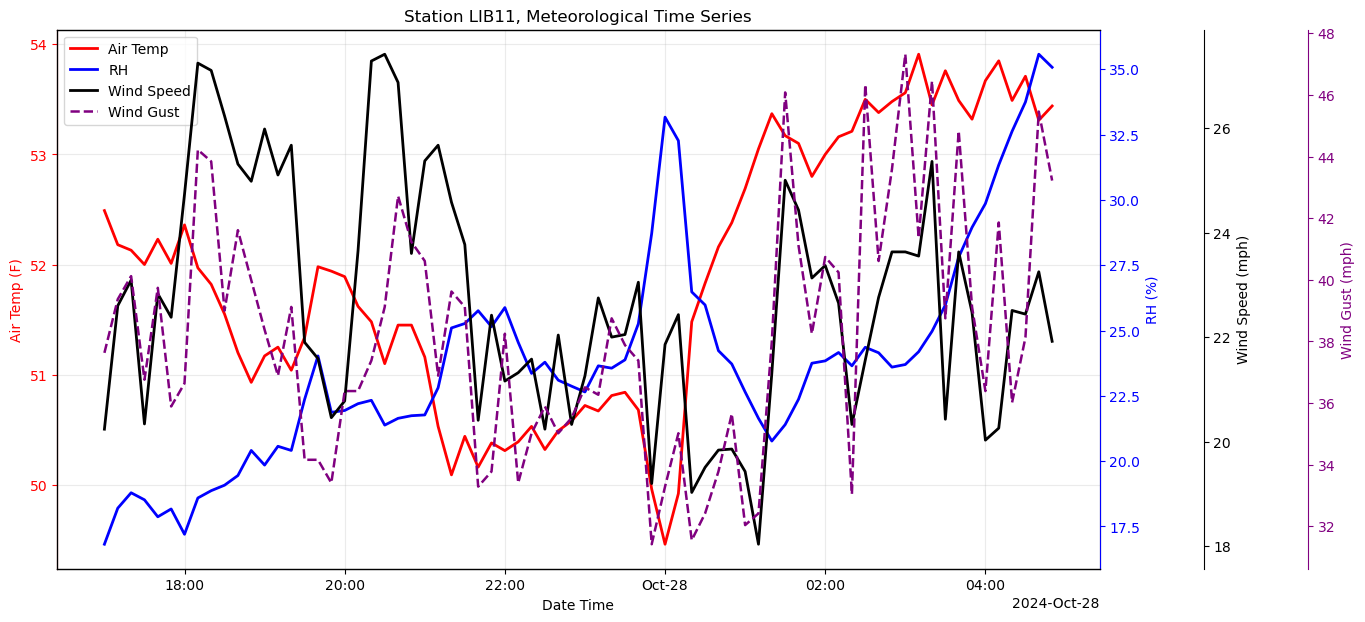

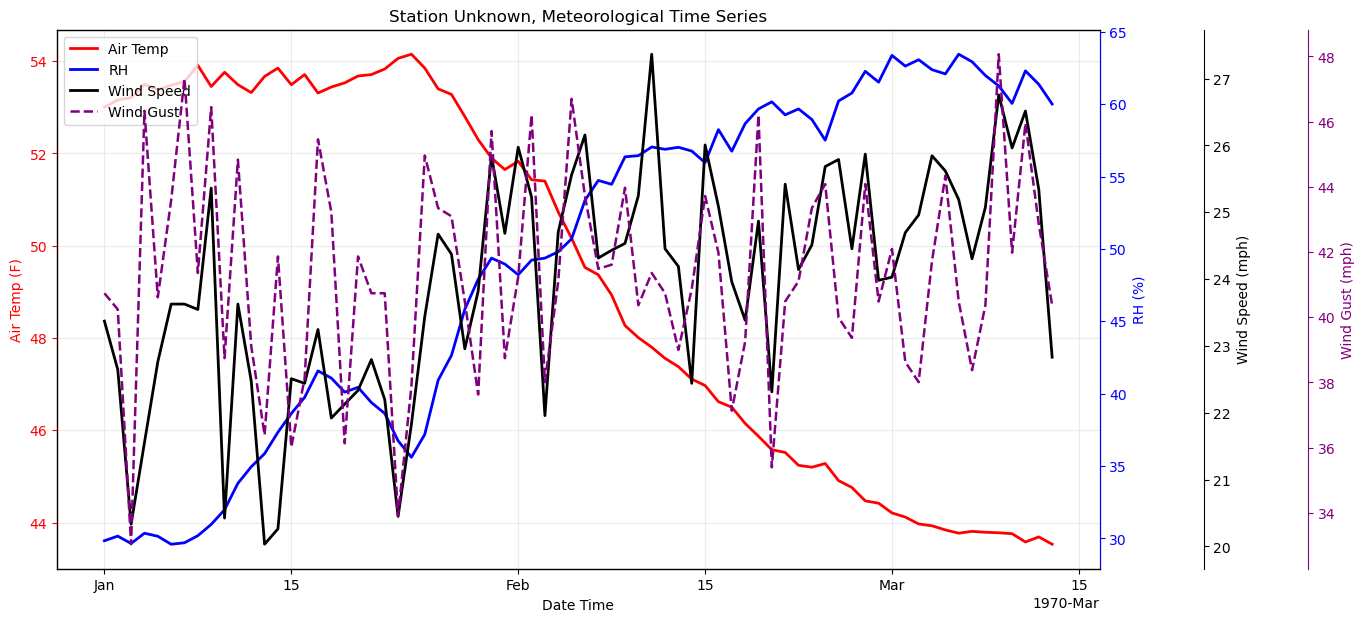

In [5]:
plot_weather_data(df_common)
plot_weather_data(df_synoptic)

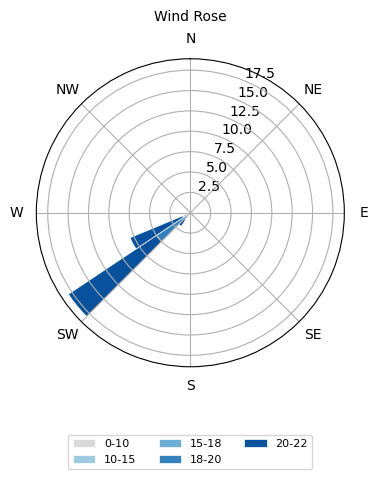

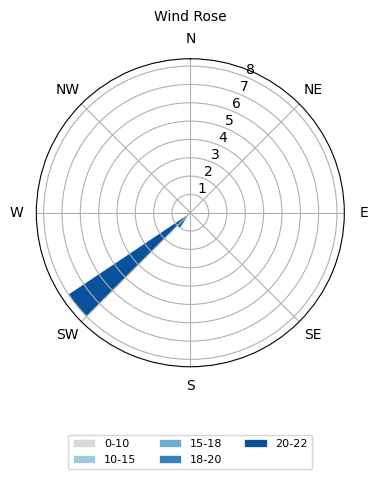

In [6]:
plot_wind_rose(df_common)
plot_wind_rose(df_synoptic)

#### Fuel Data

Processing variable nfuel_cat
Data path found ../data/commons/Forest_SB40.tif
nfuel_cat [101. 102. 103. 121. 122. 141. 142. 144. 145. 147. 161. 162. 165. 181.
 182. 183. 184. 185. 186. 187. 188. 189.  nan]


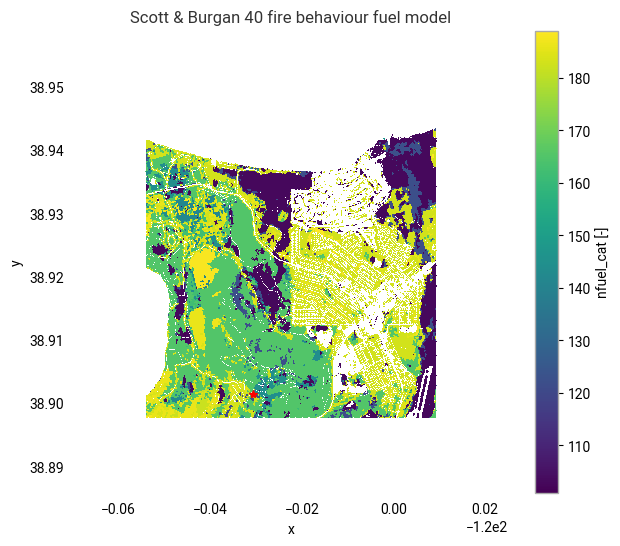

Processing variable fueldepthm
Data path found ../data/commons/Forest_depth.tif
fueldepthm [0.      0.06096 0.09144 0.12192 0.18288 0.27432 0.3048  0.4572  0.6096
 0.9144  1.8288      nan]


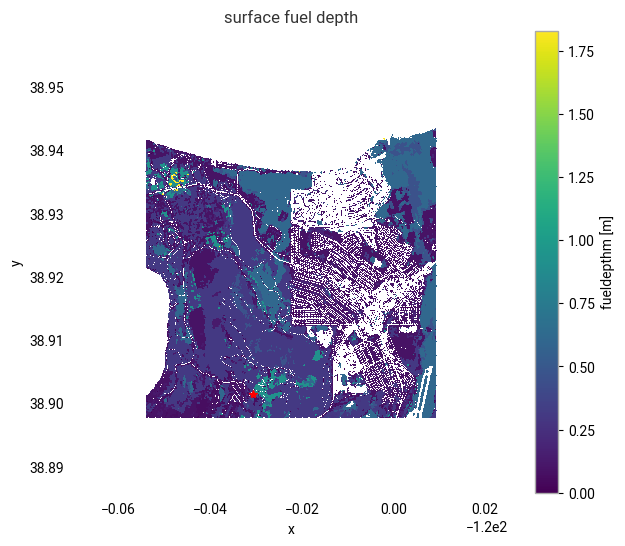

Processing variable fmc_gc01
Data path found ../data/commons/Forest_moist1.tif
fmc_gc01 [0.   0.04  nan]


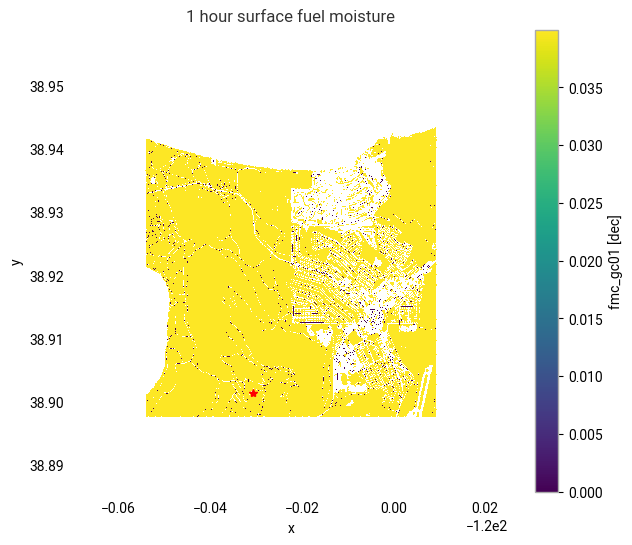

Processing variable fmc_gc02
Data path found ../data/commons/Forest_moist10.tif
fmc_gc02 [0.   0.05  nan]


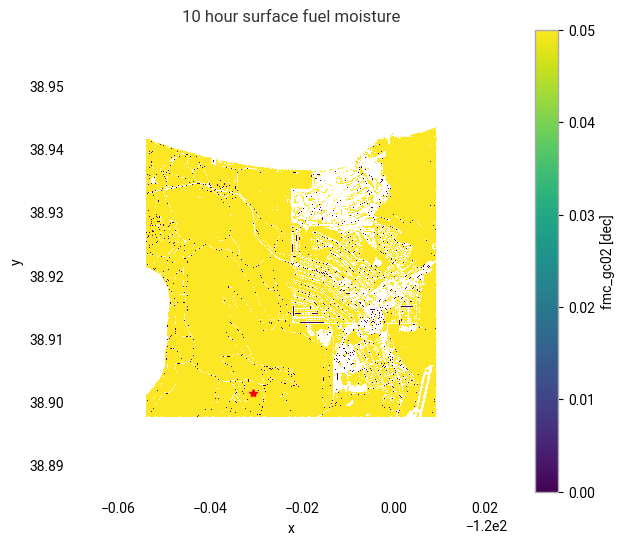

Processing variable fmc_gc03
Data path found ../data/commons/Forest_moist100.tif
fmc_gc03 [0.   0.06  nan]


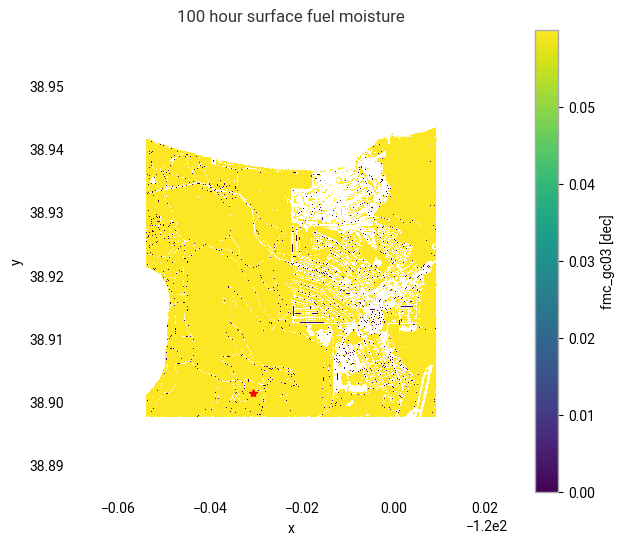

Processing variable fuelload_gc01
Data path found ../data/commons/Forest_rhof1.tif
fuelload_gc01 [0.        0.067251  0.089668  0.112085  0.156919  0.1905445 0.2129615
 0.22417   0.246587  0.2577955 0.3026295 0.313838  0.358672  0.538008
 0.784595  0.807012  0.89668   1.300186  1.4907305       nan]


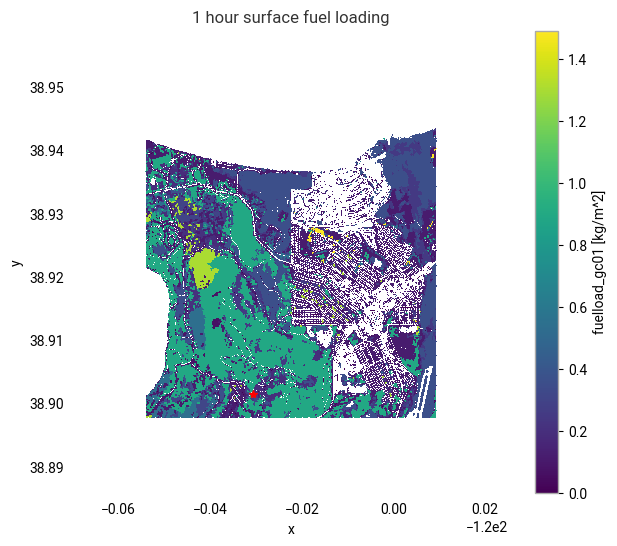

Processing variable fuelload_gc02
Data path found ../data/commons/Forest_rhof10.tif
fuelload_gc02 [0.        0.0560425 0.089668  0.112085  0.201753  0.2577955 0.269004
 0.313838  0.336255  0.403506  0.470757  0.493174  0.515591  0.538008
 0.560425  0.739761  0.89668   1.188101        nan]


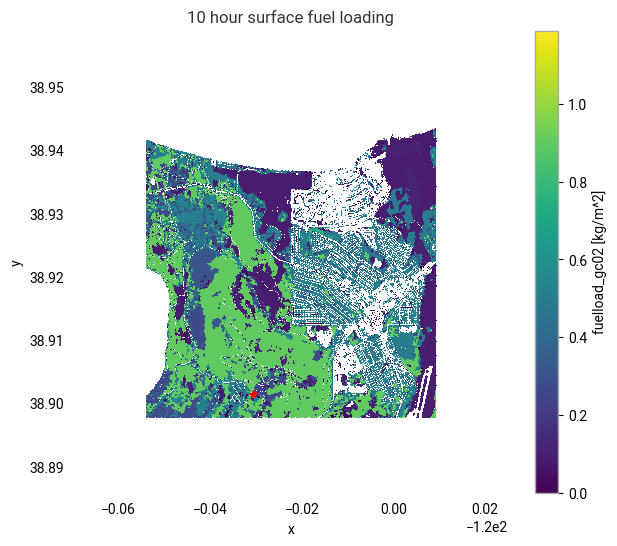

Processing variable fuelload_gc03
Data path found ../data/commons/Forest_rhof100.tif
fuelload_gc03 [0.        0.044834  0.1681275 0.246587  0.269004  0.2802125 0.336255
 0.493174  0.627676  0.67251   0.807012  0.9303055 0.941514  0.986348
 1.815777        nan]


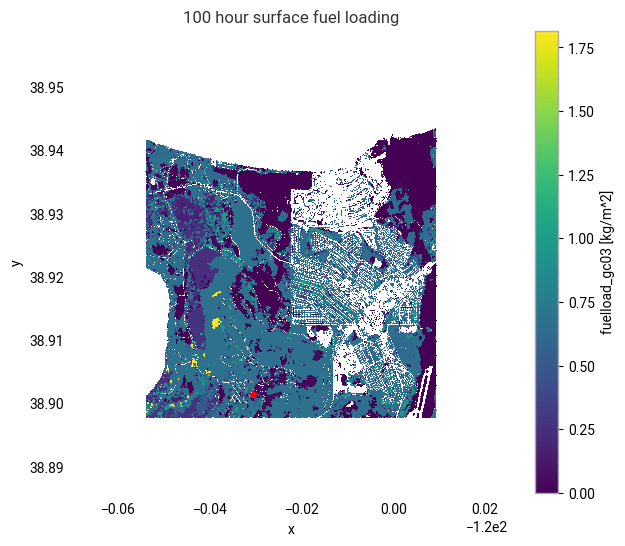

Processing variable savr
Data path found ../data/commons/Forest_SAV.tif
savr [2460.75 4921.5  5905.8  6562.   7218.2      nan]


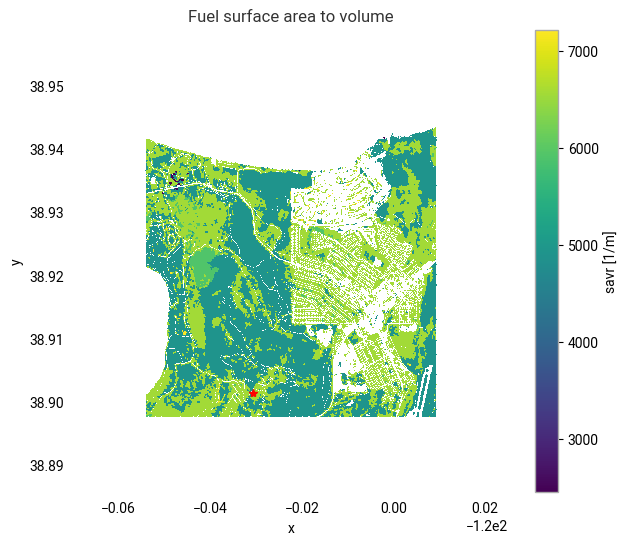

In [7]:
# Read and process fuels data
ds = read_fuels_data(comm_data_path, case_id, ign_coords, wx_coords)

In [8]:
# Check fuel properties
check_fuel_props(ds)

,nfuel_cat,count,fueldepthm,fuelload_gc01,fuelload_gc02,fuelload_gc03,savr
0,101,13044,0.12192,0.089668,0.000000,0.000000,7218.200195
1,102,27886,0.30480,0.246587,0.000000,0.000000,6562.000000
2,103,866080,0.60960,0.358672,0.089668,0.000000,4921.500000
3,121,13884,0.27432,0.156919,0.000000,0.000000,6562.000000
4,122,243593,0.45720,0.246587,0.112085,0.000000,6562.000000
5,141,2962,0.30480,0.089668,0.056042,0.000000,6562.000000
6,142,72398,0.30480,0.302630,0.538008,0.168128,6562.000000
7,144,135661,0.91440,0.190545,0.257796,0.044834,6562.000000
8,145,5472,1.82880,0.807012,0.470757,0.000000,2460.750000
9,147,185,1.82880,0.784595,1.188101,0.493174,2460.750000


#### Terrain

zsf [1865.3461 1865.4222 1865.4619 ... 2194.078  2194.1526       nan]


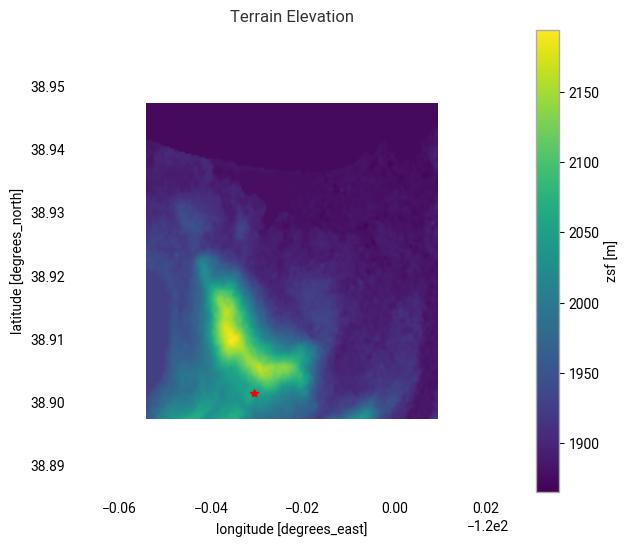

In [9]:
# Read and process elevation data
ds_temp = read_temp_dataset(tmp_base_path)
da = read_terrain_data(elevation_base_path, ds_temp, ign_coords, wx_coords)

#### Define center of domain

In [10]:
# Define domain center and print coordinates
xc, yc = define_domain_center(da, shift=[0, 200])
print("Center domain: ({}, {})".format(xc, yc))
print("Ignition location: ({}, {})".format(ign_coords[0], ign_coords[1]))

Center domain: (-120.02234226322922, 38.91818008215245)
Ignition location: (-120.0306, 38.9014)


#### Building Data

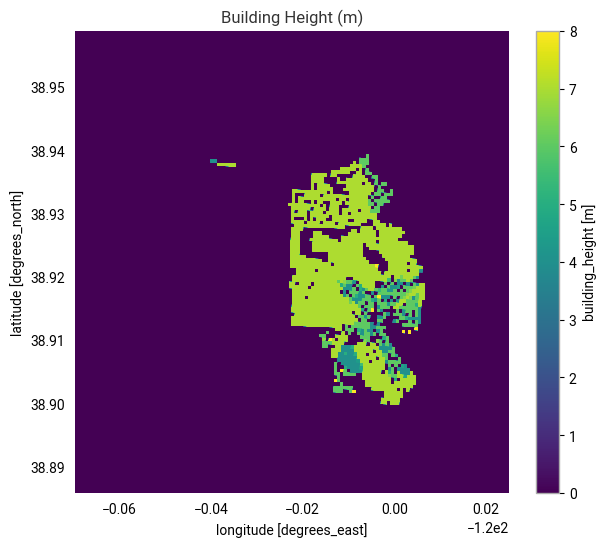

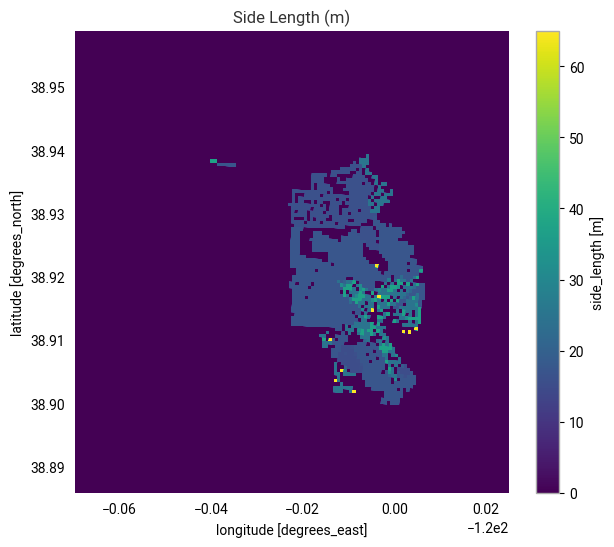

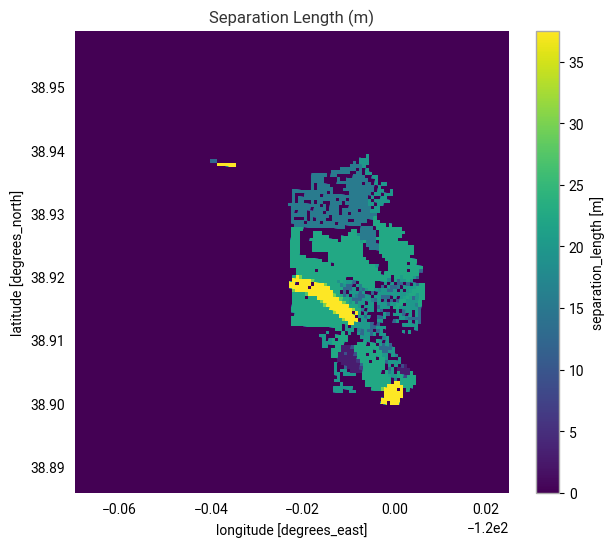

In [11]:
# Read building property data at a coarser resolution
gdf_build = read_building_data(building_base_path)
ds_building_props = rasterize_buildings(gdf_build, ds_temp)
plot_building_rasters(ds_building_props)

In [12]:
# Get WUDAT classes from building properties
wudapt_classes = get_wudapt_classes(ds_building_props)

In [13]:
# Add variables to general dataset
ds = add_variable_to_ds(ds, ds_building_props["side_length"].data.astype(np.float32), "side_length")
ds = add_variable_to_ds(ds, ds_building_props["separation_length"].data.astype(np.float32), "separation_length")
ds = add_variable_to_ds(ds, ds_building_props["building_height"].data.astype(np.float32), "building_height")
ds = add_variable_to_ds(ds, wudapt_classes, "wudapt_classes")

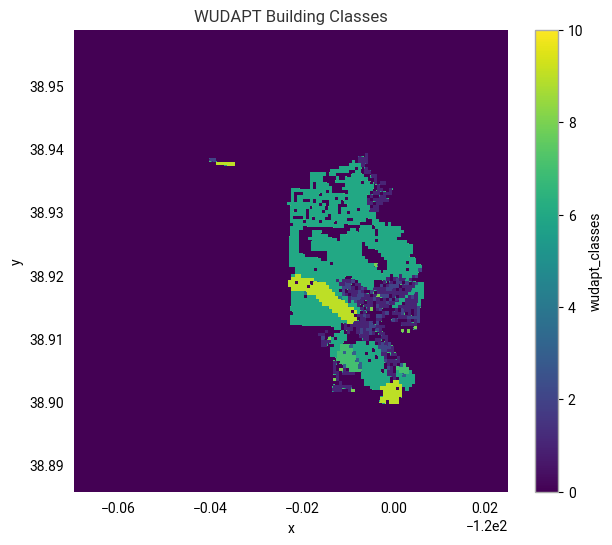

In [14]:
# Plot final WUDAPT classes
ds.wudapt_classes.plot()
plt.title("WUDAPT Building Classes")
plt.show()

In [15]:
# Store final GeoTIFF files
ds.side_length.rio.to_raster(osp.join(output_data_path, f"{case_id}_side_length.tif"), compress="LZW")
ds.separation_length.rio.to_raster(osp.join(output_data_path, f"{case_id}_separation_length.tif"), compress="LZW")
ds.building_height.rio.to_raster(osp.join(output_data_path, f"{case_id}_building_height.tif"), compress="LZW")

#### Roads

In [16]:
# Read and process road data
gdf_roads = read_road_data(roads_base_path)
road_da = rasterize_roads(gdf_roads, ds_temp)

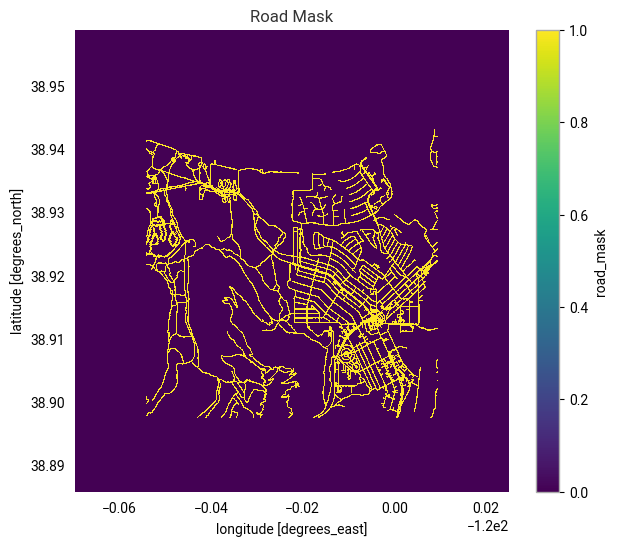

In [17]:
road_da.plot()
plt.title("Road Mask")
plt.show()

#### Get urbanized fuel category map

In [18]:
# Get fuel categories combining vegetation and urban classes
ds = define_nfuel_cat_urban(ds, wudapt_classes, road_da)

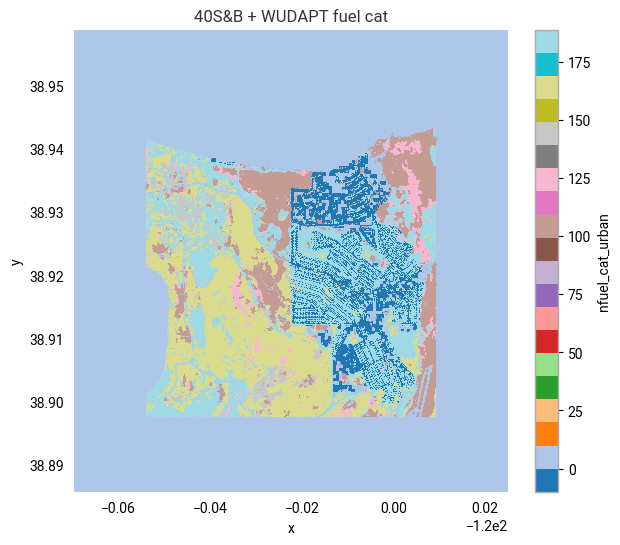

In [19]:
# Plot urbanized fuel classes map
ds.nfuel_cat_urban.plot(cmap="tab20", vmin=ds.nfuel_cat_urban.min(), vmax=ds.nfuel_cat_urban.max())
plt.title("40S&B + WUDAPT fuel cat")
plt.show()

In [20]:
# Write final GeoTIFF file
ds.nfuel_cat_urban.rio.to_raster(osp.join(output_data_path, f"{case_id}_nfuelcat_urban.tif"), compress="LZW")

#### Tree Properties

In [21]:
# Read tree property data
gdf_trees = read_tree_data(tree_base_path)

In [22]:
# Rasterize tree data and store in dataset
ds_trees = rasterize_trees(gdf_trees, ds_temp)

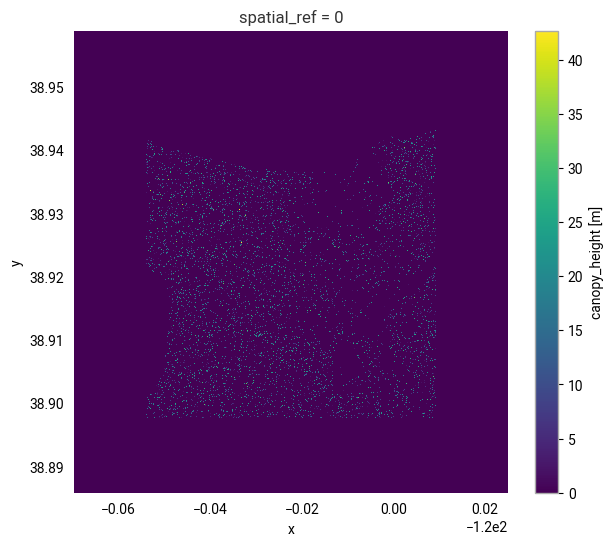

In [23]:
# Plot canopy height raster
ds_trees.canopy_height.plot()

In [25]:
# Transform units for WRF-SFIRE
ds_trees["canopy_height"] *= 10.
ds_trees["canopy_base_height"] *= 10.
ds_trees["canopy_bulk_density"] *= 100.

In [26]:
# Write final GeoTIFF file
ds_trees.canopy_height.rio.to_raster(osp.join(output_data_path, f"{case_id}_can_top.tif"), compress="LZW")
ds_trees.canopy_height.rio.to_raster(osp.join(output_data_path, f"{case_id}_can_top.tif"), compress="LZW")
ds_trees.canopy_base_height.rio.to_raster(osp.join(output_data_path, f"{case_id}_can_bottom.tif"), compress="LZW")
ds_trees.canopy_bulk_density.rio.to_raster(osp.join(output_data_path, f"{case_id}_can_bulk_density.tif"), compress="LZW")